### **Algoritmo de Prim**
El algoritmo de Prim empieza desde un nodo arbitrario y crece un árbol añadiendo, en cada paso, la arista de menor peso que conecte un nuevo vértice al árbol ya construido.

**Proceso:**
- Iniciar con cualquier nodo arbitrario del grafo.
- Añadir la arista de menor peso que conecta un vértice en el árbol con un vértice fuera del árbol.
- Repetir este proceso hasta que todos los vértices estén en el árbol.

Prim explora el grafo poco a poco, expandiendo el árbol desde un nodo inicial hasta cubrir todos los nodos, garantizando siempre la elección de la arista de menor peso en cada expansión.

In [34]:
import os
import sys

dir = os.getcwd()
root_dir = os.path.abspath(os.path.join(dir, os.pardir))
sys.path.append(root_dir)

from utils import graphs

In [35]:

%%file 1.graph
2 5 3 1
2 6 6 8
0 5 1 6 5 1 6 6
0 1 5 6
6 5
2 1 3 6
1 8 2 6 4 5 7 2
6 1
     

Overwriting 1.graph


In [36]:
with open('1.graph') as file:
    G = []
    for line in file:
        if line.startswith('-'):
            G.append([])
            continue
        nums = list(map(int, line.split()))
        G.append([(nums[i], nums[i+1]) for i in range(0, len(nums), 2)])

    print(G)

[[(2, 5), (3, 1)], [(2, 6), (6, 8)], [(0, 5), (1, 6), (5, 1), (6, 6)], [(0, 1), (5, 6)], [(6, 5)], [(2, 1), (3, 6)], [(1, 8), (2, 6), (4, 5), (7, 2)], [(6, 1)], []]


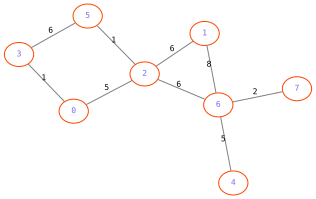

In [37]:
graphs.show(G, weighted=True, layout='neato')

In [38]:
import heapq
import math

def prim(G):
    n = len(G)
    visited = [False]*n
    g = [math.inf]*n
    path = [-1]*n
    pq = []
    heapq.heappush(pq, (0, 0)) # (g(s), s)
    while pq:
        _, u = heapq.heappop(pq)
        visited[u] = True
        for v, w in G[u]:
            if not visited[v] and w < g[v]:
                g[v] = w
                path[v] = u
                heapq.heappush(pq, (w, v))

    return path

In [39]:
path = prim(G)
print(path)

[-1, 2, 0, 0, 6, 2, 2, 6, -1]


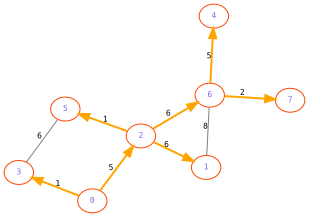

In [40]:
graphs.show(G, weighted=True, layout='neato', path=path)